In [4]:
import math 
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon


w0 = [1,0,0,0]
w1 = [0,1,0,0]
w2 = [0,0,1,0]
w3 = [0,0,0,1]
w4 = [-1,1,-1,1]
w5 = [-1,0,0,0]
w6 = [0,-1,0,0]
w7 = [0,0,-1,0]
w8 = [0,0,0,-1]
w9 =[1,-1,1,-1]

v_1_g  = [1, 0, 1, -1]
v_z_g  = [1, 0, 1, 0]
v_z2_g = [0, 1, 0, 1]
v_z3_g = [-1, 1, 0, 1]

EDGE_COLOR = (0.15, 0.12, 0.1, 0.25)  # warm gray
SHADOW_COLOR = (0, 0, 0, 0.12)
DRAW_EDGES = False
edges = []

def add_edge(v1, v2, color='k-'):
    if not DRAW_EDGES:
        return
    edges.append((v1, v2))
    plt.plot([v1[0], v2[0]], [v1[1], v2[1]], color)

    
# def add_edge(v1, v2, color='k-'):
#     edges.append((v1, v2))
#     plt.plot([v1[0], v2[0]], [v1[1], v2[1]], color)

    
R=[[0,1,0,0], [0,0,1,0],[0,0,0,1],[-1,1,-1,1]] # Matriz de rotación 
W= np.array([[1, 0],[math.cos(36*math.pi/180), math.sin(36*math.pi/180)],[math.cos(72*math.pi/180), math.sin(72*math.pi/180)],[math.cos(108*math.pi/180), math.sin(108*math.pi/180)]]) #Matriz de Mapeo

O=[0,0,0,0] #origen
origin = [1,2,3,4]
v_originales  = [O,w0,np.add(w0,w2),w2] #rombo gordo
v_originaless = [O,w0,np.add(w0,w1),w1] #rombo delgado
translation_vector = [x - y for x, y in zip(origin, [0, 0, 0, 0])] #se lo sumas al origin


def vertices_tras(v_originales_new, translation_vector,f,t):
    translated_vertices_new= [[[x + y for x, y in zip(vertex, translation_vector)] for vertex in v_originales_new],0,f,t]
    return translated_vertices_new

translated_vertices_new1N=vertices_tras(v_originales, translation_vector,0,0)
translated_vertices_new1d1N=vertices_tras(v_originaless, translation_vector,0,0)

In [5]:
# def sample_image_color(x, y, bounds, img_arr):
#     (xmin, xmax, ymin, ymax) = bounds

#     # normalize to [0,1]
#     u = (x - xmin) / (xmax - xmin)
#     v = (y - ymin) / (ymax - ymin)

#     # flip y (image coords go down)
#     v = 1 - v

#     # clamp
#     u = np.clip(u, 0, 1)
#     v = np.clip(v, 0, 1)

#     px = int(u * (img_arr.shape[1] - 1))
#     py = int(v * (img_arr.shape[0] - 1))

#     return img_arr[py, px] / 255.0

# def radial_depth(cx, cy, bounds):
#     xmin, xmax, ymin, ymax = bounds
#     mx = 0.5 * (xmin + xmax)
#     my = 0.5 * (ymin + ymax)
#     d = np.sqrt((cx - mx)**2 + (cy - my)**2)
#     dmax = np.sqrt((xmax - mx)**2 + (ymax - my)**2)
#     return 1 - d / dmax
# def quantize_color(rgb, levels=6):
#     return np.round(rgb * levels) / levels


In [6]:
L_ss=[]
def graficaR2N(L):
    Lx=[]
    Ly=[]
    ss=[np.dot(k,W) for k in L]
    L_ss.append(ss)
    for k in range(len(ss)):
        add_edge(ss[k], ss[k-1], '-k')
        Lx.append(ss[k][0])
        Ly.append(ss[k][1])
    return L_ss, Lx, Ly


In [7]:
def project_vertices(L):
    """Project 4D Penrose vertices to 2D WITHOUT drawing"""
    ss = [np.dot(k, W) for k in L]
    Lx = [p[0] for p in ss]
    Ly = [p[1] for p in ss]
    return Lx, Ly


In [8]:
import numpy as np

class Rombo:
    def __init__(self, origin, v_originales,v_originaless):
        self.origin = origin
        self.v_originales = v_originales
        self.v_originaless = v_originaless

    def inf_v(self, vertices):
        v_inflados = []
        for i in range(len(vertices)):
            result = np.dot(vertices[i][0], v_1_g) + np.dot(vertices[i][1], v_z_g) + \
                     np.dot(vertices[i][2], v_z2_g) + np.dot(vertices[i][3], v_z3_g)
            v_inflados.append(result)
        return v_inflados

    def ShiftssN(self, vertices, shift_vector, val):
        shift = vertices[0] + np.dot(shift_vector, np.linalg.matrix_power(R, val))
        return shift

    def GenverticesN(self, vecO, orient, shift_Mif, f, tipo):
        Rt = np.linalg.matrix_power(R, orient)
        trans = [np.dot(i, Rt) for i in vecO]
        transs = [[np.add(s, shift_Mif[0]) for s in trans], orient, f[1], tipo]
        return transs
    def apply_ruleG(self, Lvec, shift_vector, val, name):
        for j in Lvec:
            v_inflados_Mif = self.inf_v(j[0])
            v_inflados_tMif = np.add(self.origin, v_inflados_Mif)
            shifts_Mif = self.ShiftssN(v_inflados_tMif, self.inf_v([shift_vector]), j[1])
            L_vertices_Mif = self.GenverticesN(self.v_originales, j[1]+val, shifts_Mif, j[0], name)
        return L_vertices_Mif
    def apply_ruleD(self, Lvec, shift_vector, val, name):
        for j in Lvec:
            v_inflados_Mif = self.inf_v(j[0])
            v_inflados_tMif = np.add(self.origin, v_inflados_Mif)
            shifts_Mif = self.ShiftssN(v_inflados_tMif, self.inf_v([shift_vector]), j[1])
            L_vertices_Mif = self.GenverticesN(self.v_originaless, j[1]+val, shifts_Mif, j[0], name)
        return L_vertices_Mif
        
rombo_instance = Rombo(origin, v_originales,v_originaless)
# rombo_instance.translated_vertices = translated_vertices_new1N


RG1 = rombo_instance.apply_ruleG([translated_vertices_new1N],[1, 0, 1, 0], val=-5, name="RomboG") #[1, 0, 1, 0] -5
RG2 = rombo_instance.apply_ruleG([translated_vertices_new1N],[1, 0, 0, 0], val=-6, name="RomboG")
RG3 = rombo_instance.apply_ruleG([translated_vertices_new1N],[0, 0, 1, 0], val=6, name="RomboG") #[0, 0, 1, 0]
RD1 = rombo_instance.apply_ruleD([translated_vertices_new1d1N],[1, -1, 1, 0], val=-1, name="RomboD1")
RD2 = rombo_instance.apply_ruleD([translated_vertices_new1d1N],[0, 1, 0, 1], val=-3, name="RomboD2")

rD1 = rombo_instance.apply_ruleD([translated_vertices_new1d1N],[0,2,-1,1],val=-3, name="RomboD1") #[0,2,-1,1]
rD2 = rombo_instance.apply_ruleD([translated_vertices_new1d1N],[1,0,0,0],val=3, name="RomboD2") #[1,0,0,0]
rG1 = rombo_instance.apply_ruleG([translated_vertices_new1d1N],[1,1,0,0],val=5, name="RomboG1")
rG2 = rombo_instance.apply_ruleG([translated_vertices_new1N],[0,0,0,0],val=-1, name="RomboG2")

NI1 = rombo_instance.apply_ruleG([translated_vertices_new1N],[0, 0, 0, 0], val=2, name="RomboG")
NI2 = rombo_instance.apply_ruleG([translated_vertices_new1N],[0, 0, 0, 0], val=-2, name="RomboG")
NI3 = rombo_instance.apply_ruleG([translated_vertices_new1N],[0, 0, 0, 0], val=0, name="RomboG")
NI4 = rombo_instance.apply_ruleG([translated_vertices_new1N],[0, 0, 0, 0], val=-4, name="RomboG")
NI5 = rombo_instance.apply_ruleG([translated_vertices_new1N],[0, 0, 0, 0], val=4, name="RomboG")

ni1 = rombo_instance.apply_ruleD([translated_vertices_new1d1N],[0,0,1,0],val=-1, name="RomboD1")
ni2 = rombo_instance.apply_ruleD([translated_vertices_new1d1N],[1,0,0,0],val=3, name="RomboD2")
mi1 = rombo_instance.apply_ruleG([translated_vertices_new1d1N],[0,1,1,0],val=-3, name="RomboG1")
mi2 = rombo_instance.apply_ruleG([translated_vertices_new1N],[0,0,0,0],val=-1, name="RomboG2")


MI1 = rombo_instance.apply_ruleG([translated_vertices_new1N],[1, 0, 0, 0], val=-6, name="RomboG")
MI2 = rombo_instance.apply_ruleD([translated_vertices_new1d1N],[1,-1,1,0],val=-1, name="RomboD1")
MI3 = rombo_instance.apply_ruleD([translated_vertices_new1d1N],[1,0,1,-1],val=-5, name="RomboD2")


dII1= rombo_instance.apply_ruleD([translated_vertices_new1d1N],[0,0,0,0],val=0, name="RomboD1")
dII2 = rombo_instance.apply_ruleD([translated_vertices_new1d1N],[0,0,0,0],val=1, name="RomboD2")
dII3 = rombo_instance.apply_ruleD([translated_vertices_new1d1N],[0,0,0,0],val=2, name="RomboD2")
dII4 = rombo_instance.apply_ruleD([translated_vertices_new1d1N],[0,0,0,0],val=3, name="RomboD2")
dII5 = rombo_instance.apply_ruleD([translated_vertices_new1d1N],[0,0,0,0],val=4, name="RomboD2")
dII6 = rombo_instance.apply_ruleD([translated_vertices_new1d1N],[0,0,0,0],val=5, name="RomboD2")
dII7 = rombo_instance.apply_ruleD([translated_vertices_new1d1N],[0,0,0,0],val=6, name="RomboD2")
dII8 = rombo_instance.apply_ruleD([translated_vertices_new1d1N],[0,0,0,0],val=7, name="RomboD2")
dII9 = rombo_instance.apply_ruleD([translated_vertices_new1d1N],[0,0,0,0],val=8, name="RomboD2")
dII10 = rombo_instance.apply_ruleD([translated_vertices_new1d1N],[0,0,0,0],val=9, name="RomboD2")

tI1= rombo_instance.apply_ruleD([translated_vertices_new1d1N],[0,0,0,0],val=0, name="RomboD1")
tI2 = rombo_instance.apply_ruleD([translated_vertices_new1d1N],[0,0,0,0],val=6, name="RomboD2")
tI3 = rombo_instance.apply_ruleD([translated_vertices_new1d1N],[0,0,0,0],val=-2, name="RomboD2")
tI4 = rombo_instance.apply_ruleD([translated_vertices_new1d1N],[0,0,0,0],val=3, name="RomboD1")
tI5 = rombo_instance.apply_ruleD([translated_vertices_new1d1N],[0,0,0,0],val=4, name="RomboD1")


TestI=[tI1,tI2,tI3]

tryon=[MI1,MI2,MI3]
Lnuevo2=[ni1,ni2,mi1,mi2]
LnuevoI=[NI1, NI2, NI3, NI4, NI5]
LGordo=[RG1,RG2,RG3,RD1,RD2]
LDelgado=[rD1,rD2,rG1,rG2]
LnuevoII=[dII1,dII2,dII3,dII4,dII5,dII6,dII7,dII8,dII9,dII10]
for i in LnuevoII:
    graficaR2N(i[0])
    print(i)
plt.pause(0.1) 
plt.figure(figsize=(12, 8))
plt.pause(0.1) 

[[array([ 0,  9,  6, 10]), array([ 1,  9,  6, 10]), array([ 1, 10,  6, 10]), array([ 0, 10,  6, 10])], 0, [2, 2, 3, 4], 'RomboD1']
[[array([ 0,  9,  6, 10]), array([ 0, 10,  6, 10]), array([ 0, 10,  7, 10]), array([ 0,  9,  7, 10])], 1, [2, 2, 3, 4], 'RomboD2']
[[array([ 0,  9,  6, 10]), array([ 0,  9,  7, 10]), array([ 0,  9,  7, 11]), array([ 0,  9,  6, 11])], 2, [2, 2, 3, 4], 'RomboD2']
[[array([ 0,  9,  6, 10]), array([ 0,  9,  6, 11]), array([-1, 10,  5, 12]), array([-1, 10,  5, 11])], 3, [2, 2, 3, 4], 'RomboD2']
[[array([ 0,  9,  6, 10]), array([-1, 10,  5, 11]), array([-2, 10,  5, 11]), array([-1,  9,  6, 10])], 4, [2, 2, 3, 4], 'RomboD2']
[[array([ 0,  9,  6, 10]), array([-1,  9,  6, 10]), array([-1,  8,  6, 10]), array([ 0,  8,  6, 10])], 5, [2, 2, 3, 4], 'RomboD2']
[[array([ 0,  9,  6, 10]), array([ 0,  8,  6, 10]), array([ 0,  8,  5, 10]), array([ 0,  9,  5, 10])], 6, [2, 2, 3, 4], 'RomboD2']
[[array([ 0,  9,  6, 10]), array([ 0,  9,  5, 10]), array([0, 9, 5, 9]), array([0, 

<Figure size 1200x800 with 0 Axes>

In [19]:
import time
import colorsys
import numpy as np
ORIENTATION_COLORS = {
    0:"#ff6b35", #"#ABE0F0" "#6f0000",  #colors
    1:"#f7c59f", #"#E50046", #"#65000b",  # blue
    2:"#efefd0", #"#FDAB9E", #"#801818",  # green
    3:"#004e89", #"#C7DB9C", #"#701c1c",  # purple
    4:"#1a659e" #"#FFF0BD" #"#800000",  # orange
}
STYLE = "orientation"  
# try:
# "orientation"
# "edges"
# "radial"
# "depth"
# "chaos"
# "negative"
# "3d"


class TessellationIterator:
    def __init__(self, initial_tessellation, origin, v_originales, v_originaless):
        self.tessellation = initial_tessellation
        self.origin = origin
        self.v_originales = v_originales
        self.v_originaless = v_originaless

    def orientation_class(self, orient):
        return orient % 5

    def tile_color(self, tile):
        orient = tile[1]
        k = self.orientation_class(orient)
        return ORIENTATION_COLORS[k]
    
    def compute_bounds(self, tiles):
        xs, ys = [], []
        for t in tiles:
            _, Lx, Ly = graficaR2N(t[0])
            xs.extend(Lx)
            ys.extend(Ly)
        return min(xs), max(xs), min(ys), max(ys)

    def fill(self, results):
        for j in results:
            Lx, Ly = project_vertices(j[0])
            color = self.tile_color(j)
            plt.fill(Lx, Ly, color=color, edgecolor='none')
            
#     def fill(self, results):
#         bounds = self.compute_bounds(results)

#         for tile in results:
#             _, Lx, Ly = graficaR2N(tile[0])

#             # tile center
#             cx = np.mean(Lx)
#             cy = np.mean(Ly)

#             # sample image
#             color = sample_image_color(cx, cy, bounds, IMG_ARR)

#             plt.fill(Lx, Ly, color=color, edgecolor='none')

#     def fill(self, results, ax):
#         bounds = self.compute_bounds(results)

#         for tile in results:
#             _, Lx, Ly = graficaR2N(tile[0])
#             Lx = np.array(Lx)
#             Ly = np.array(Ly)

#             cx = np.mean(Lx)
#             cy = np.mean(Ly)

#             jitter = 0.01
#             color = sample_image_color(
#                 cx + jitter * np.random.randn(),
#                 cy + jitter * np.random.randn(),
#                 bounds,
#                 IMG_ARR
#             )
#             color = np.array(color[:3])

#             grain = 0.92 + 0.12 * np.random.rand()
#             color *= grain

#             depth = radial_depth(cx, cy, bounds)
#             color *= (0.85 + 0.25 * depth)

#             color = quantize_color(color, levels=6)
#             color = np.clip(color, 0, 1)

#             # shadow
#             ax.fill(
#                 Lx + 0.008, Ly - 0.008,
#                 color=SHADOW_COLOR,
#                 linewidth=0
#             )

#             # tile
#             ax.fill(
#                 Lx, Ly,
#                 color=color,
#                 edgecolor=EDGE_COLOR,
#                 linewidth=0.35
#             )



    def inflation(self, lvec):
        L = []
        for j in lvec:
            if j[3] == "RomboG" or j[3] == "RomboG1" or j[3] == "RomboG2":
                RG1 = rombo_instance.apply_ruleG([j],[1, 0, 1, 0], val=-5, name="RomboG") #-5
                RG2 = rombo_instance.apply_ruleG([j],[1, 0, 0, 0], val=-6, name="RomboG")
                RG3 = rombo_instance.apply_ruleG([j],[0, 0, 1, 0], val=6, name="RomboG") #[0, 0, 1, 0]
                RD1 = rombo_instance.apply_ruleD([j],[1, -1, 1, 0], val=-1, name="RomboD1")#-1
                RD2 = rombo_instance.apply_ruleD([j],[0, 1, 0, 1], val=-3, name="RomboD2")
                L.append(RG1)
                L.append(RG2)
                L.append(RG3)
                L.append(RD1)
                L.append(RD2)
            if j[3] == "RomboD1" or j[3] == "RomboD2":
                rD1 = rombo_instance.apply_ruleD([j],[0,2,-1,1],val=-3, name="RomboD1")
                rD2 = rombo_instance.apply_ruleD([j],[1,0,0,0],val=3, name="RomboD2")
                rG1 = rombo_instance.apply_ruleG([j],[1,1,0,0],val=5, name="RomboG1")
                rG2 = rombo_instance.apply_ruleG([j],[0,0,0,0],val=-1, name="RomboG2")
                L.append(rD1)
                L.append(rD2)
                L.append(rG1)
                L.append(rG2)
        return L

    def remove_duplicates(self, lvec):
        seen = set()
        result = []

        for l in lvec:
            frozen = frozenset(tuple(arr) for arr in l[0])
            if frozen not in seen:
                seen.add(frozen)
                result.append(l)

        return result, seen

    def graph_iteratively(self, results):
        for j in results:
            graficaR2N(j[0])
     
        
    def iterate_and_graph(self, num_iterations):
        for _ in range(num_iterations):
            start_time = time.time()
            self.tessellation = self.inflation(self.tessellation)
            end_time = time.time()
            iteration_time = end_time - start_time
            print(f"Iteration time: {iteration_time} seconds")
    
        result, _ = self.remove_duplicates(self.tessellation)
        self.graph_iteratively(result)
        self.fill(result)


plt.pause(0.1) 
plt.figure(figsize=(25, 25))
plt.figure(figsize=(40, 40), dpi=300)
plt.axis('off')

# initial_tessellation=LnuevoI
# tessellation_iterator = TessellationIterator(initial_tessellation, origin, v_originales, v_originaless)
# tessellation_iterator.iterate_and_graph(5)

initial_tessellation=LnuevoI
tessellation_iterator = TessellationIterator(initial_tessellation, origin, v_originales, v_originaless)
tessellation_iterator.iterate_and_graph(0)



# x = 6.04508497
# y = 20.50697153
# k = [8.16311896, 22.0458133]
# k2 = [6.85410197, 21.09475678]

#plt.scatter(x, y, color='orange', marker='o', label='O translated origin',s=100)
#plt.scatter(k[0], k[1], color='blue', marker='o', label=r'$\tilde{\omega}$')
# plt.scatter(k[0], k[1], color='#8BC34A', marker='>', label=r'$\omega^0 + \omega^2$', s=100)
# plt.scatter(k[0], k[1], color='blue', marker='o', label=r'$\tilde{\omega}$', s=100)

# plt.legend(fontsize=23)
# fig, ax = plt.subplots(figsize=(80, 50))
# ax.set_aspect('equal')
# ax.set_xlim(-1, 3)
# ax.set_ylim(-1, 3)
plt.axis('equal') 

(4.280698433968601, 7.500454515405927, 18.814245585908328, 22.19969747680111)

<Figure size 2500x2500 with 0 Axes>

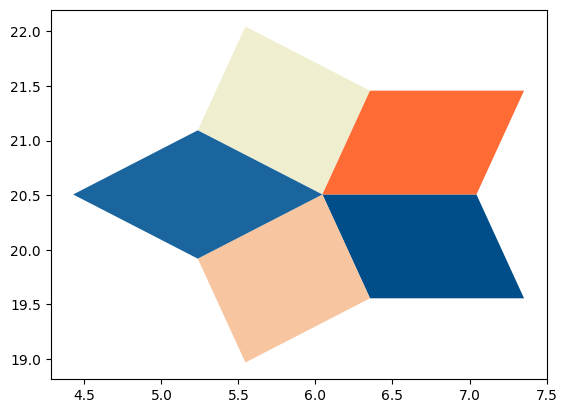

In [20]:
initial_tessellation = LnuevoI

tessellation_iterator = TessellationIterator(
    initial_tessellation,
    origin,
    v_originales,
    v_originaless
)

tessellation_iterator.iterate_and_graph(0)

#8 iteraciones con la imagen roj

Iteration time: 0.036752939224243164 seconds
Iteration time: 0.06603503227233887 seconds
Iteration time: 0.24412798881530762 seconds


(29.633048651498616, 45.26207297724793, 119.6662041420678, 136.09953282229415)

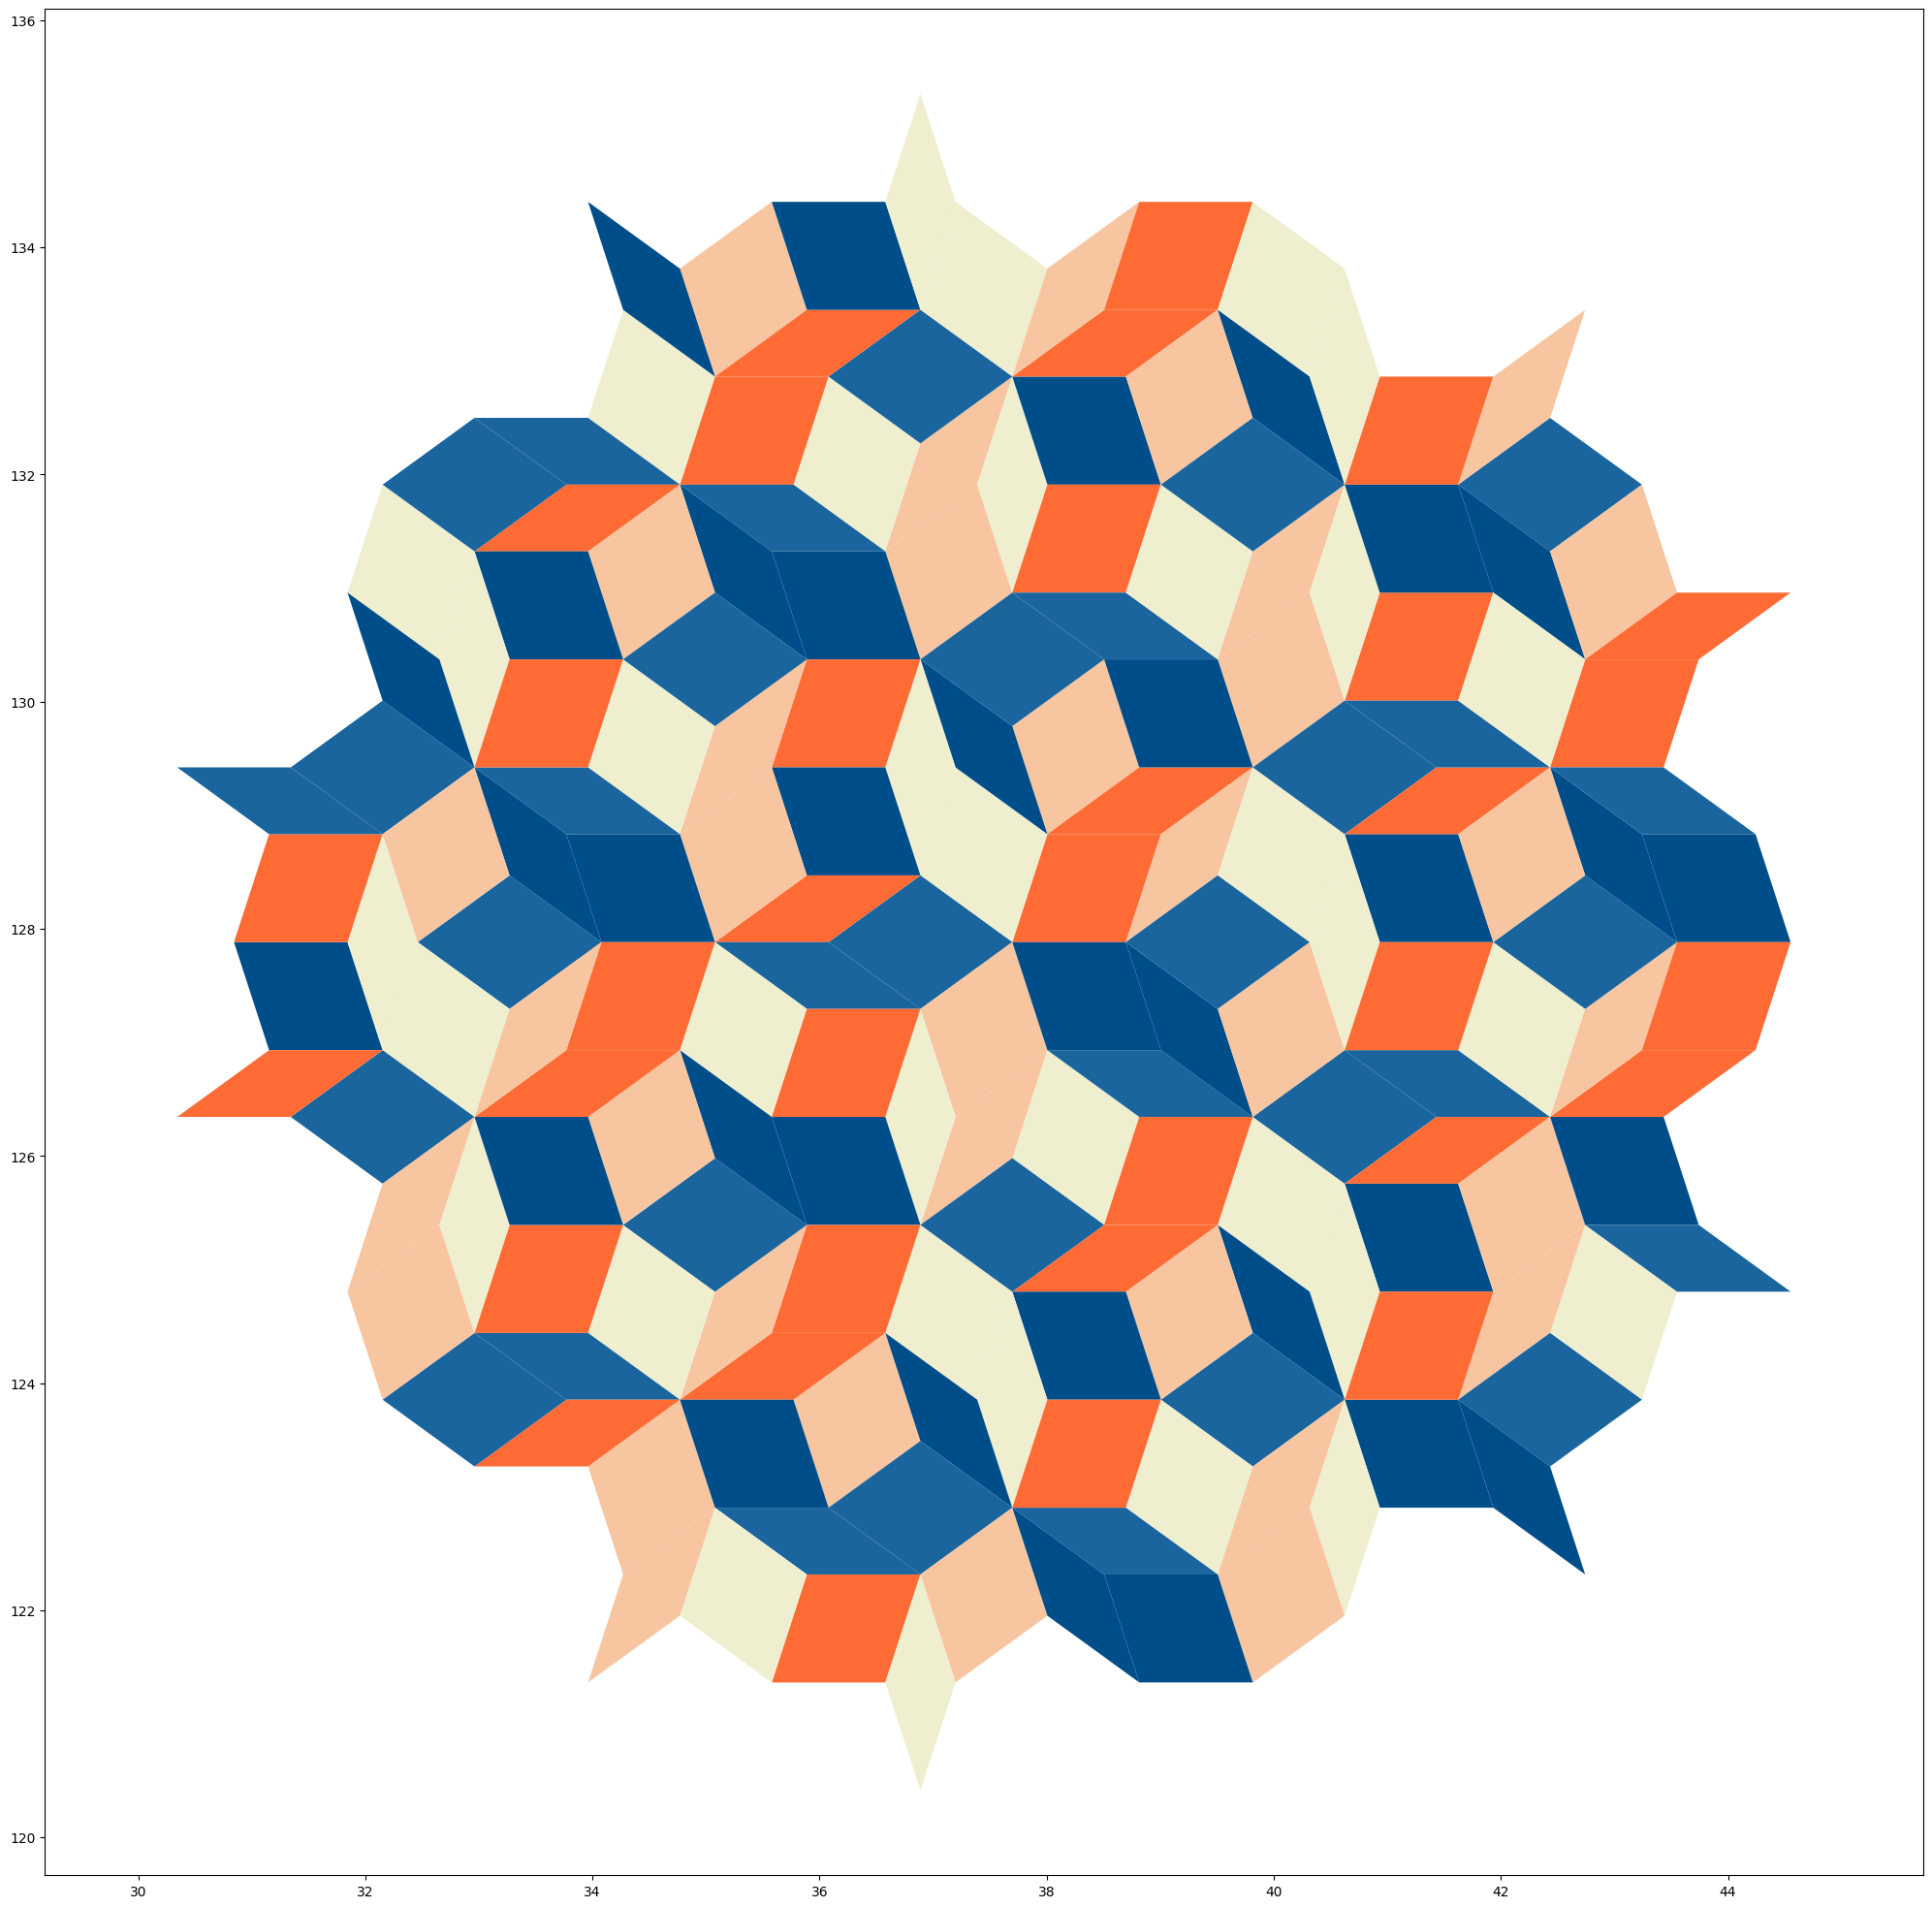

In [24]:

plt.figure(figsize=(25, 25))
initial_tessellation=LnuevoI
tessellation_iterator = TessellationIterator(initial_tessellation, origin, v_originales, v_originaless)
tessellation_iterator.iterate_and_graph(3)

# x = 6.04508497
# y = 20.50697153
# k = [8.16311896, 22.0458133]
# k2 = [6.85410197, 21.09475678]

#plt.scatter(x, y, color='orange', marker='o', label='O translated origin',s=100)
#plt.scatter(k[0], k[1], color='blue', marker='o', label=r'$\tilde{\omega}$')
# plt.scatter(k[0], k[1], color='#8BC34A', marker='>', label=r'$\omega^0 + \omega^2$', s=100)
# plt.scatter(k[0], k[1], color='blue', marker='o', label=r'$\tilde{\omega}$', s=100)

# plt.legend(fontsize=23)
# fig, ax = plt.subplots(figsize=(80, 50))
# ax.set_aspect('equal')
# ax.set_xlim(-1, 3)
# ax.set_ylim(-1, 3)
plt.axis('equal') 